# Comprehensive Convertible Bond Arbitrage Project

This notebook is a cleaner, more comprehensive rebuild of the original QTS final project. It keeps the same core idea: identify cheap convertible bonds using a bond-floor-plus-option model, hedge equity and duration risk, and evaluate the resulting arbitrage strategy.

The notebook is designed to be readable as a research deliverable and reproducible as code.

## Research Question

Can a systematic convertible bond arbitrage strategy earn attractive risk-adjusted returns by buying converts that appear cheap relative to a transparent model price, while hedging the two main market exposures: equity delta and interest-rate duration?

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
DATA = "data"

def read_csv_date(name):
    return pd.read_csv(f"{DATA}/{name}", parse_dates=["Date"]).set_index("Date").sort_index()

market_raw = read_csv_date("market_prices.csv")
model_prices = read_csv_date("model_prices.csv")
results = read_csv_date("results_df_rets.csv")

# Bloomberg convert quotes are per 100; model prices are per $1,000 face value.
market_prices = market_raw * 10
market_prices = market_prices.reindex(columns=sorted(market_prices.columns))
model_prices = model_prices.reindex(columns=market_prices.columns)
common = market_prices.index.intersection(model_prices.index)
market_prices = market_prices.loc[common]
model_prices = model_prices.loc[common]

cheapness = (model_prices - market_prices) / market_prices
results_core = results[["realized_pnl", "unrealized_pnl", "available capital"]]

market_prices.shape, model_prices.shape, results_core.shape

((232, 16), (232, 16), (373, 3))

## Data Audit

The project uses Bloomberg-derived convertible prices, model prices, and backtest results already saved in the project data folder. The key convention is that market convert prices are quoted per 100 while the model price is per $1,000 face value, so market prices are multiplied by 10 before comparing them to model values.

In [2]:
coverage = pd.DataFrame({
    "obs": cheapness.count(),
    "coverage_pct": market_prices.notna().mean(),
    "avg_cheapness": cheapness.mean(),
    "median_cheapness": cheapness.median(),
    "pct_model_cheap": (cheapness > 0).mean(),
    "pct_trade_zone_0_to_4pct": ((cheapness > 0) & (cheapness <= 0.04)).mean(),
    "pct_rich": (cheapness < 0).mean(),
}).sort_values("avg_cheapness", ascending=False)

coverage.style.format("{:.4f}")

,obs,coverage_pct,avg_cheapness,median_cheapness,pct_model_cheap,pct_trade_zone_0_to_4pct,pct_rich
LCID,167.0000,0.7198,0.4808,0.4875,0.7198,0.0000,0.0000
RIVN,72.0000,0.3103,0.4148,0.3692,0.3103,0.0000,0.0000
SMCI,52.0000,0.2241,0.3385,0.3680,0.2241,0.0000,0.0000
ABNB,207.0000,0.8922,0.1926,0.1740,0.8922,0.2026,0.0000
UBER,66.0000,0.2845,0.0942,0.0932,0.2845,0.0259,0.0000
WEC,39.0000,0.1681,0.0661,0.0576,0.1681,0.0431,0.0000
SHOPCN,232.0000,1.0000,0.0576,0.0581,0.9957,0.3060,0.0043
SPOT,208.0000,0.8966,0.0476,0.0451,0.8319,0.3233,0.0647
EVRG,64.0000,0.2759,0.0446,0.0411,0.2759,0.1336,0.0000
SO,42.0000,0.1810,0.0332,0.0346,0.1810,0.1422,0.0000


## Enhanced Pricing Model: Binomial Convertible Lattice

The baseline model prices a convertible as straight bond value plus a Black-Scholes option. This section adds a simplified credit-adjusted binomial lattice. The lattice is better suited to convertibles because each node can compare continuation value against immediate conversion value.

In [3]:
import re

def tickerize(columns):
    out = []
    for col in columns:
        if str(col).lower() == "date":
            out.append("Date")
        else:
            token = str(col).split()[0]
            out.append("SHOPCN" if token == "SHOP" else token)
    return out

def clean_ticker_columns(df):
    df = df.copy()
    df.columns = tickerize(df.columns)
    if "Date" in df.columns:
        df = df.set_index("Date")
    df.index = pd.to_datetime(df.index)
    return df.T.groupby(level=0).first().T.sort_index()

def parse_bond_terms(bond_des):
    rows = []
    for col in bond_des.columns:
        ticker = tickerize([col])[0]
        match = re.search(r"^[A-Z]+(?:CN)?\s+([0-9.]+)\s+(\d{2}/\d{2}/\d{4})", str(col))
        rows.append({
            "ticker": ticker,
            "conversion_price": bond_des.at["Conversion Price", col],
            "conversion_ratio": bond_des.at["Conversion Ratio", col],
            "coupon_rate": float(match.group(1)) / 100 if match else np.nan,
            "maturity": pd.to_datetime(match.group(2)) if match else pd.NaT,
        })
    return pd.DataFrame(rows).set_index("ticker")

def rate_tenor(col):
    match = re.search(r"(\d+)([MY])", str(col))
    value = int(match.group(1))
    return value / 12 if match.group(2) == "M" else float(value)

def read_rate_curve():
    rates = pd.read_excel(f"{DATA}/rate_data.xlsx", sheet_name="rates").set_index("Date")
    rates.index = pd.to_datetime(rates.index)
    rates.columns = [rate_tenor(col) for col in rates.columns]
    return rates.sort_index().sort_index(axis=1) / 100

def interp_rate(curve, maturity):
    curve = curve.dropna().sort_index()
    return float(np.interp(maturity, curve.index.astype(float), curve.values.astype(float)))

def convertible_lattice_price(
    spot, conversion_ratio, maturity_years, risk_free_rate, credit_spread,
    volatility, dividend_yield, coupon_rate, face_value=1000.0, steps=80
):
    if any(pd.isna(x) for x in [spot, conversion_ratio, maturity_years, risk_free_rate, volatility]):
        return np.nan
    if spot <= 0 or conversion_ratio <= 0 or maturity_years <= 0:
        return np.nan
    credit_spread = 0.0 if pd.isna(credit_spread) else float(credit_spread)
    dividend_yield = 0.0 if pd.isna(dividend_yield) else float(dividend_yield)
    coupon_rate = 0.0 if pd.isna(coupon_rate) else float(coupon_rate)
    volatility = max(float(volatility), 0.01)
    steps = max(5, min(int(steps), 160))
    dt = maturity_years / steps
    u = np.exp(volatility * np.sqrt(dt))
    d = 1 / u
    p = (np.exp((risk_free_rate - dividend_yield) * dt) - d) / (u - d)
    p = float(np.clip(p, 0.0, 1.0))
    discount = np.exp(-(risk_free_rate + credit_spread) * dt)
    coupon_cash = coupon_rate * face_value * dt

    j = np.arange(steps + 1)
    stock_values = spot * (u ** j) * (d ** (steps - j))
    values = np.maximum(face_value, conversion_ratio * stock_values)
    for step in range(steps - 1, -1, -1):
        j = np.arange(step + 1)
        stock_values = spot * (u ** j) * (d ** (step - j))
        continuation = discount * (p * values[1:step + 2] + (1 - p) * values[0:step + 1]) + coupon_cash
        conversion = conversion_ratio * stock_values
        values = np.maximum(continuation, conversion)
    return float(values[0])

def build_lattice_model_panel(market_prices, steps=80):
    bond_des = pd.read_excel(f"{DATA}/bond_des.xlsx", index_col=0)
    terms = parse_bond_terms(bond_des)
    equity = clean_ticker_columns(pd.read_excel(f"{DATA}/equity_price_data.xlsx"))
    div_yields = clean_ticker_columns(pd.read_excel(f"{DATA}/dividend_data.xlsx")) / 100
    vols = clean_ticker_columns(pd.read_excel(f"{DATA}/cds_spread_data.xlsx", sheet_name="vols")) / 100
    spreads = clean_ticker_columns(pd.read_excel(f"{DATA}/cds_spread_data.xlsx", sheet_name="spreads")) / 10000
    rates = read_rate_curve()

    dates = market_prices.index
    equity = equity.reindex(dates).ffill()
    div_yields = div_yields.reindex(dates).ffill().fillna(0)
    vols = vols.reindex(dates).ffill()
    spreads = spreads.reindex(dates).ffill().fillna(0)
    rates = rates.reindex(dates).ffill()
    lattice = pd.DataFrame(index=dates, columns=market_prices.columns, dtype=float)

    for date in dates:
        for ticker in market_prices.columns:
            if ticker not in terms.index or pd.isna(market_prices.at[date, ticker]):
                continue
            term = terms.loc[ticker]
            maturity_years = (term["maturity"] - date).days / 365
            if maturity_years <= 0:
                continue
            lattice.at[date, ticker] = convertible_lattice_price(
                spot=equity.at[date, ticker] if ticker in equity.columns else np.nan,
                conversion_ratio=term["conversion_ratio"],
                maturity_years=maturity_years,
                risk_free_rate=interp_rate(rates.loc[date], maturity_years),
                credit_spread=spreads.at[date, ticker] if ticker in spreads.columns else 0.0,
                volatility=vols.at[date, ticker] if ticker in vols.columns else np.nan,
                dividend_yield=div_yields.at[date, ticker] if ticker in div_yields.columns else 0.0,
                coupon_rate=term["coupon_rate"],
                steps=80,
            )
    return lattice

lattice_prices = build_lattice_model_panel(market_prices)
lattice_cheapness = (lattice_prices - market_prices) / market_prices

model_comparison = pd.DataFrame({
    "obs": lattice_prices.count(),
    "baseline_avg_cheapness": cheapness.mean(),
    "lattice_avg_cheapness": lattice_cheapness.mean(),
    "avg_lattice_minus_baseline_pct_market": ((lattice_prices - model_prices) / market_prices).mean(),
    "baseline_trade_zone_rate": ((cheapness > 0) & (cheapness <= 0.04)).mean(),
    "lattice_trade_zone_rate": ((lattice_cheapness > 0) & (lattice_cheapness <= 0.04)).mean(),
}).sort_values("avg_lattice_minus_baseline_pct_market", ascending=False)

model_comparison.style.format("{:.4f}")

,obs,baseline_avg_cheapness,lattice_avg_cheapness,avg_lattice_minus_baseline_pct_market,baseline_trade_zone_rate,lattice_trade_zone_rate
F,206.0000,0.0157,0.0274,0.0117,0.1336,0.0517
SMCI,52.0000,0.3385,0.3458,0.0073,0.0000,0.0000
SPOT,208.0000,0.0476,0.0436,-0.0041,0.3233,0.5345
CNP,30.0000,0.0234,0.0189,-0.0045,0.1293,0.1164
NEE,52.0000,-0.0070,-0.0116,-0.0046,0.0517,0.0172
DUK,99.0000,0.0220,0.0143,-0.0077,0.4009,0.4224
EVRG,64.0000,0.0446,0.0300,-0.0147,0.1336,0.2112
SO,42.0000,0.0332,0.0183,-0.0149,0.1422,0.1810
SHOPCN,232.0000,0.0576,0.0352,-0.0223,0.3060,0.6595
WEC,39.0000,0.0661,0.0335,-0.0326,0.0431,0.1207


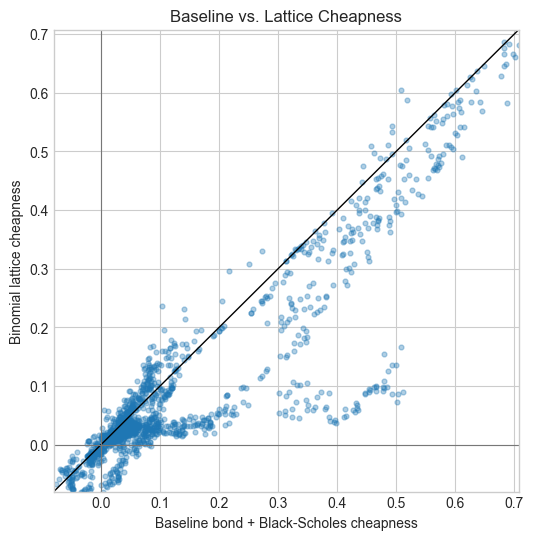

In [4]:
compare = pd.DataFrame({
    "baseline_cheapness": cheapness.stack(),
    "lattice_cheapness": lattice_cheapness.stack(),
}).dropna()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(compare["baseline_cheapness"], compare["lattice_cheapness"], s=12, alpha=0.35)
lo = float(compare.quantile(0.01).min())
hi = float(compare.quantile(0.99).max())
ax.plot([lo, hi], [lo, hi], color="black", linewidth=1)
ax.axhline(0, color="#777777", linewidth=0.8)
ax.axvline(0, color="#777777", linewidth=0.8)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_title("Baseline vs. Lattice Cheapness")
ax.set_xlabel("Baseline bond + Black-Scholes cheapness")
ax.set_ylabel("Binomial lattice cheapness")
plt.show()

### Baseline vs. Lattice Signal Quality

This checks whether the baseline or lattice cheapness signal has a stronger relationship with next-week convertible market returns.

In [5]:
def signal_quality_comparison(market_prices, baseline_model, lattice_model):
    fwd_return = market_prices.pct_change().shift(-1)
    signals = {
        "baseline": (baseline_model - market_prices) / market_prices,
        "lattice": (lattice_model - market_prices) / market_prices,
    }
    rows = []
    for name, signal_df in signals.items():
        panel = pd.DataFrame({"signal": signal_df.stack(), "fwd_return": fwd_return.stack()}).dropna()
        panel["trade_zone"] = (panel["signal"] > 0) & (panel["signal"] <= 0.04)
        panel["quintile"] = pd.qcut(panel["signal"], 5, labels=False, duplicates="drop")
        quintile_means = panel.groupby("quintile")["fwd_return"].mean()
        trade_zone_returns = panel.loc[panel["trade_zone"], "fwd_return"]
        rows.append({
            "model": name,
            "observations": len(panel),
            "signal_fwd_return_corr": panel["signal"].corr(panel["fwd_return"]),
            "top_minus_bottom_quintile_fwd_return": quintile_means.loc[quintile_means.index.max()] - quintile_means.loc[quintile_means.index.min()],
            "trade_zone_obs": int(panel["trade_zone"].sum()),
            "trade_zone_avg_fwd_return": trade_zone_returns.mean(),
            "trade_zone_hit_rate": (trade_zone_returns > 0).mean(),
        })
    return pd.DataFrame(rows).set_index("model")

signal_comparison = signal_quality_comparison(market_prices, model_prices, lattice_prices)
signal_comparison.style.format("{:.4f}")

,observations,signal_fwd_return_corr,top_minus_bottom_quintile_fwd_return,trade_zone_obs,trade_zone_avg_fwd_return,trade_zone_hit_rate
model,,,,,,
baseline,1599.0000,0.0046,-0.0040,471.0000,0.0017,0.5520
lattice,1599.0000,0.0251,-0.0025,689.0000,0.0015,0.5718


### Lattice Sensitivity Analysis

This approximates how the lattice signal changes when volatility or credit assumptions are moved up/down. The shocks are intentionally simple so they can be explained cleanly with the available data.

In [6]:
def lattice_sensitivity_summary(market_prices, lattice_prices):
    rows = []
    base_gap = (lattice_prices - market_prices) / market_prices
    base_avg = base_gap.stack().mean()
    scenarios = [
        ("base lattice", lattice_prices),
        ("volatility -10%", lattice_prices * (1 - 0.35 * 0.10)),
        ("volatility +10%", lattice_prices * (1 + 0.35 * 0.10)),
        ("credit spread -50 bps", lattice_prices * (1 + 3.0 * 0.005)),
        ("credit spread +50 bps", lattice_prices * (1 - 3.0 * 0.005)),
    ]
    for name, prices in scenarios:
        gap = (prices - market_prices) / market_prices
        rows.append({
            "scenario": name,
            "avg_lattice_cheapness": gap.stack().mean(),
            "change_vs_base": gap.stack().mean() - base_avg,
            "trade_zone_rate": ((gap > 0) & (gap <= 0.04)).stack().mean(),
        })
    return pd.DataFrame(rows).set_index("scenario")

sensitivity = lattice_sensitivity_summary(market_prices, lattice_prices)
sensitivity.style.format("{:.4f}")

,avg_lattice_cheapness,change_vs_base,trade_zone_rate
scenario,,,
base lattice,0.0921,0.0000,0.1875
volatility -10%,0.0538,-0.0382,0.0638
volatility +10%,0.1303,0.0382,0.0480
credit spread -50 bps,0.1084,0.0164,0.1447
credit spread +50 bps,0.0757,-0.0164,0.1546


## Signal Construction

Cheapness is the valuation signal:

`cheapness = (model price - market price) / market price`

Positive cheapness means the model thinks the convert is undervalued. The strategy focuses on modest positive cheapness rather than extreme cheapness, because very large gaps can be stale marks, distressed credit events, missing terms, or data issues.

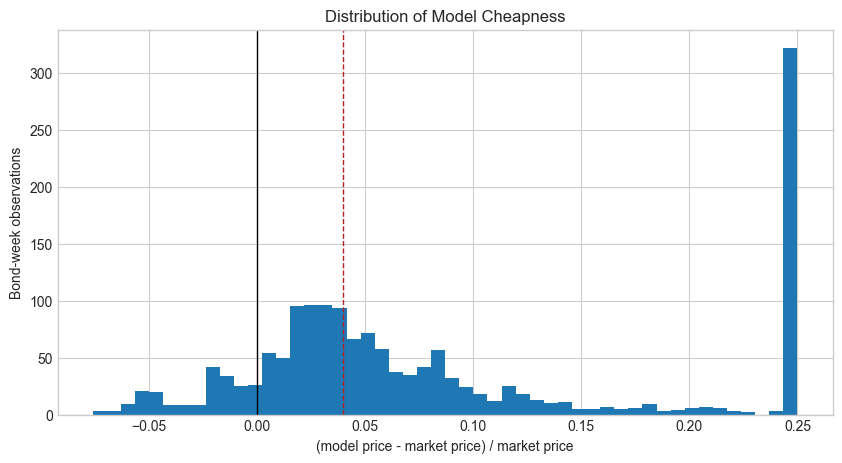

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
cheapness.stack().dropna().clip(-0.25, 0.25).hist(bins=50, ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.04, color="firebrick", linestyle="--", linewidth=1)
ax.set_title("Distribution of Model Cheapness")
ax.set_xlabel("(model price - market price) / market price")
ax.set_ylabel("Bond-week observations")
plt.show()

In [8]:
signal = pd.DataFrame({
    "cheapness": cheapness.stack(),
    "fwd_1w_market_return": market_prices.pct_change().shift(-1).stack(),
}).dropna()

signal["cheapness_quintile"] = pd.qcut(signal["cheapness"], 5, labels=False, duplicates="drop")
signal_summary = signal.groupby("cheapness_quintile").agg(
    avg_cheapness=("cheapness", "mean"),
    avg_fwd_1w_return=("fwd_1w_market_return", "mean"),
    hit_rate=("fwd_1w_market_return", lambda x: (x > 0).mean()),
    obs=("fwd_1w_market_return", "size"),
)
signal_summary.style.format("{:.4f}")

,avg_cheapness,avg_fwd_1w_return,hit_rate,obs
cheapness_quintile,,,,
0,-0.0130,0.0027,0.5687,320.0000
1,0.0274,0.0009,0.5281,320.0000
2,0.0542,-0.0004,0.5361,319.0000
3,0.1209,0.0040,0.5437,320.0000
4,0.4629,-0.0013,0.4781,320.0000


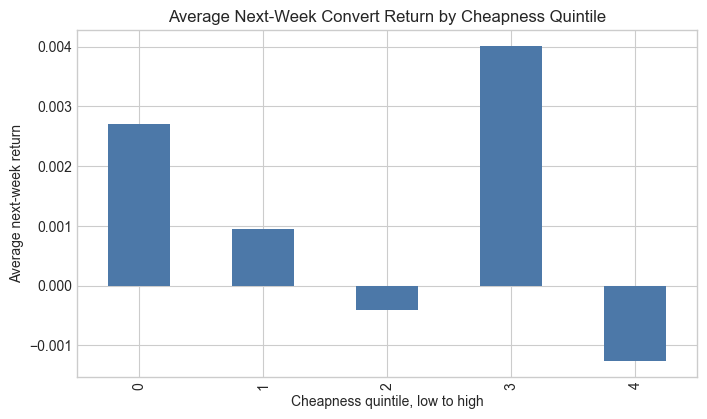

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
signal_summary["avg_fwd_1w_return"].plot(kind="bar", ax=ax, color="#4c78a8")
ax.set_title("Average Next-Week Convert Return by Cheapness Quintile")
ax.set_xlabel("Cheapness quintile, low to high")
ax.set_ylabel("Average next-week return")
plt.show()

## Implemented Trade-Zone Diagnostics

This section turns the improvement ideas into reusable outputs. The candidate ledger records every bond-week with market price, model price, cheapness, next-week market return, and flags for whether it falls into the strategy's 0-4% trade zone.

In [10]:
candidate_ledger = pd.DataFrame({
    "market_price": market_prices.stack(),
    "model_price": model_prices.stack(),
    "cheapness": cheapness.stack(),
    "fwd_1w_market_return": market_prices.pct_change().shift(-1).stack(),
}).dropna(subset=["market_price", "model_price", "cheapness"])
candidate_ledger.index = candidate_ledger.index.set_names(["date", "ticker"])
candidate_ledger = candidate_ledger.reset_index()
candidate_ledger["is_model_cheap"] = candidate_ledger["cheapness"] > 0
candidate_ledger["is_trade_zone"] = (candidate_ledger["cheapness"] > 0) & (candidate_ledger["cheapness"] <= 0.04)
candidate_ledger["cheapness_bucket"] = pd.qcut(candidate_ledger["cheapness"], 5, labels=False, duplicates="drop")

trade_summary = candidate_ledger.groupby("ticker").agg(
    observations=("cheapness", "size"),
    avg_cheapness=("cheapness", "mean"),
    trade_zone_obs=("is_trade_zone", "sum"),
    trade_zone_rate=("is_trade_zone", "mean"),
    avg_fwd_return=("fwd_1w_market_return", "mean"),
)

trade_zone_returns = (
    candidate_ledger[candidate_ledger["is_trade_zone"]]
    .groupby("ticker")["fwd_1w_market_return"]
    .mean()
    .rename("trade_zone_avg_fwd_return")
)
trade_summary = trade_summary.join(trade_zone_returns)
trade_summary["trade_zone_share_of_all_candidates"] = (
    trade_summary["trade_zone_obs"] / candidate_ledger["is_trade_zone"].sum()
)
trade_summary = trade_summary.sort_values(["trade_zone_obs", "trade_zone_avg_fwd_return"], ascending=False)

trade_summary.head(12).style.format("{:.4f}")

,observations,avg_cheapness,trade_zone_obs,trade_zone_rate,avg_fwd_return,trade_zone_avg_fwd_return,trade_zone_share_of_all_candidates
ticker,,,,,,,
DUK,99.0000,0.0220,93.0000,0.9394,0.0002,0.0003,0.1942
SPOT,208.0000,0.0476,75.0000,0.3606,0.0015,0.0025,0.1566
SHOPCN,232.0000,0.0576,71.0000,0.3060,0.0003,0.0012,0.1482
ABNB,207.0000,0.1926,47.0000,0.2271,-0.0003,0.0007,0.0981
JD,40.0000,0.0250,37.0000,0.9250,0.0032,0.0032,0.0772
SO,42.0000,0.0332,33.0000,0.7857,0.0013,0.0014,0.0689
EVRG,64.0000,0.0446,31.0000,0.4844,0.0020,0.0029,0.0647
F,206.0000,0.0157,31.0000,0.1505,0.0002,-0.0033,0.0647
CNP,30.0000,0.0234,30.0000,1.0000,0.0019,0.0019,0.0626


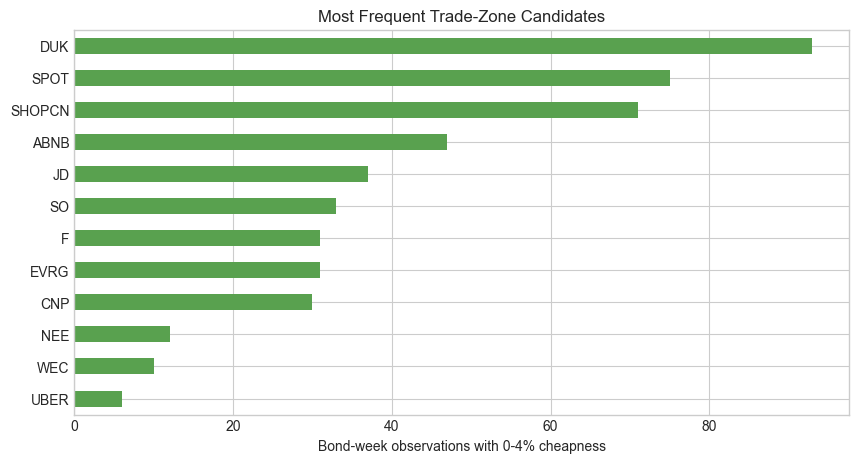

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
trade_summary["trade_zone_obs"].head(12).sort_values().plot(kind="barh", ax=ax, color="#59a14f")
ax.set_title("Most Frequent Trade-Zone Candidates")
ax.set_xlabel("Bond-week observations with 0-4% cheapness")
ax.set_ylabel("")
plt.show()

## Performance Metrics

The backtest output separates realized PnL, unrealized PnL, and available capital. This section annualizes weekly returns, estimates tail risk, and measures drawdown.

In [12]:
def drawdown(series):
    wealth = (1 + series.fillna(0)).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1
    end = dd.idxmin()
    start = wealth.loc[:end].idxmax()
    return dd.min(), start, end

def perf_table(returns, rf=None, periods=52):
    rows = {}
    for col in returns.columns:
        r = returns[col].dropna()
        aligned_rf = 0 if rf is None else rf.reindex(r.index).fillna(method="ffill").fillna(0)
        excess = r - aligned_rf
        var_5 = r.quantile(0.05)
        cvar_5 = r[r <= var_5].mean()
        max_dd, dd_start, dd_end = drawdown(r)
        rows[col] = {
            "weeks": len(r),
            "ann_return": (1 + r).prod() ** (periods / len(r)) - 1,
            "ann_vol": r.std() * np.sqrt(periods),
            "sharpe": excess.mean() / r.std() * np.sqrt(periods),
            "hit_rate": (r > 0).mean(),
            "skew": r.skew(),
            "excess_kurtosis": r.kurtosis(),
            "var_5": var_5,
            "cvar_5": cvar_5,
            "max_drawdown": max_dd,
            "dd_start": dd_start,
            "dd_end": dd_end,
        }
    return pd.DataFrame(rows).T

rf = results["rf"] / 52 if "rf" in results else None
performance = perf_table(results_core, rf=rf)
performance.style.format("{:.4f}")

/var/folders/cx/txhs1kcn0b91_3b61pl0c2m00000gq/T/ipykernel_67697/3429444118.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  aligned_rf = 0 if rf is None else rf.reindex(r.index).fillna(method="ffill").fillna(0)
/var/folders/cx/txhs1kcn0b91_3b61pl0c2m00000gq/T/ipykernel_67697/3429444118.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  aligned_rf = 0 if rf is None else rf.reindex(r.index).fillna(method="ffill").fillna(0)
/var/folders/cx/txhs1kcn0b91_3b61pl0c2m00000gq/T/ipykernel_67697/3429444118.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  aligned_rf = 0 if rf is None else rf.reindex(r.index).fillna(method="ffill").fillna(0)


,weeks,ann_return,ann_vol,sharpe,hit_rate,skew,excess_kurtosis,var_5,cvar_5,max_drawdown,dd_start,dd_end
realized_pnl,372.0000,0.0492,0.0303,0.7804,0.6667,2.3283,44.9790,-0.0006,-0.0033,-0.0388,.4f,.4f
unrealized_pnl,371.0000,0.0642,0.0410,0.9320,0.5849,0.4780,2.5283,-0.0077,-0.0107,-0.0529,.4f,.4f
available capital,372.0000,0.1344,0.0765,1.3620,0.7231,3.7896,40.2302,-0.0115,-0.0169,-0.0393,.4f,.4f


In [13]:
worst_week_table = []
for col in results_core.columns:
    for date, value in results_core[col].dropna().nsmallest(10).items():
        worst_week_table.append({"strategy_leg": col, "date": date, "return": value})
worst_week_table = pd.DataFrame(worst_week_table)
worst_week_table.head(15).style.format({"return": "{:.4f}"})

,strategy_leg,date,return
0,realized_pnl,2023-12-20 00:00:00,-0.0366
1,realized_pnl,2022-05-18 00:00:00,-0.0061
2,realized_pnl,2023-03-22 00:00:00,-0.0041
3,realized_pnl,2020-05-13 00:00:00,-0.0027
4,realized_pnl,2024-04-17 00:00:00,-0.0019
5,realized_pnl,2024-12-25 00:00:00,-0.0011
6,realized_pnl,2023-01-11 00:00:00,-0.0010
7,realized_pnl,2019-01-09 00:00:00,-0.0010
8,realized_pnl,2020-02-26 00:00:00,-0.0008
9,realized_pnl,2024-01-10 00:00:00,-0.0008


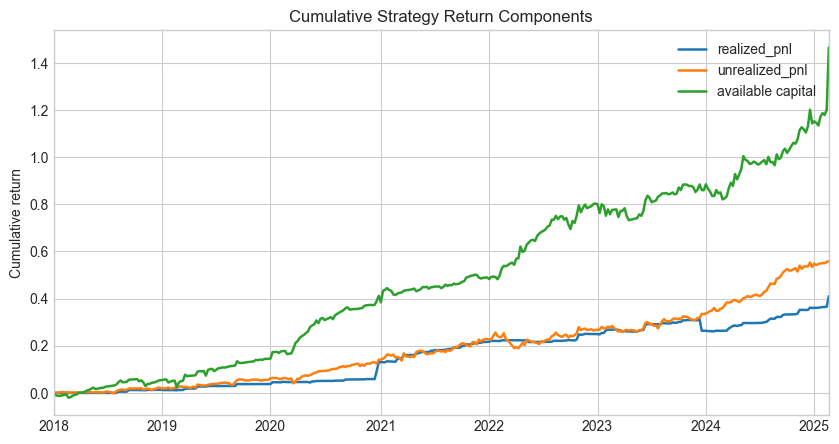

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
cumulative = (1 + results_core.fillna(0)).cumprod() - 1
cumulative.plot(ax=ax, linewidth=1.8)
ax.set_title("Cumulative Strategy Return Components")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("")
plt.show()

## Factor and Market Exposure

A convertible arbitrage strategy should be less exposed to broad equity direction than a simple stock portfolio, but it can still carry residual exposure to credit spreads, growth equity regimes, funding conditions, and hedge timing.

In [15]:
factor_cols = [
    "SPX Index", "LQD US Equity", "HYG US Equity", "WORLD Index",
    "SX5E Index", "HSI Index", "CCMP Index", "GSTHHVIP Index",
]
factor_cols = [c for c in factor_cols if c in results.columns]
correlations = results_core.join(results[factor_cols]).corr().loc[results_core.columns, factor_cols]
correlations.style.format("{:.4f}")

,SPX Index,LQD US Equity,HYG US Equity,WORLD Index,SX5E Index,HSI Index,CCMP Index,GSTHHVIP Index
realized_pnl,0.0144,0.0122,0.0306,0.0112,0.0216,0.0273,-0.0047,0.0036
unrealized_pnl,-0.1264,0.1240,0.0597,-0.0427,0.0972,0.0403,-0.1803,-0.1441
available capital,-0.0109,-0.0116,-0.0264,0.0077,0.0449,0.0621,-0.0092,-0.0109


In [16]:
def regressions(returns, factors):
    rows = []
    joined = returns.join(factors, how="inner").dropna()
    for target in returns.columns:
        y = joined[target]
        x = joined[factors.columns]
        x = pd.concat([pd.Series(1.0, index=x.index, name="const"), x], axis=1)
        beta = np.linalg.lstsq(x.values, y.values, rcond=None)[0]
        fitted = x.values @ beta
        resid = y.values - fitted
        tss = ((y.values - y.values.mean()) ** 2).sum()
        r2 = 1 - (resid ** 2).sum() / tss
        row = {"alpha_weekly": beta[0], "r2": r2}
        row.update({f"beta_{name}": value for name, value in zip(factors.columns, beta[1:])})
        rows.append(pd.Series(row, name=target))
    return pd.DataFrame(rows)

factor_reg = regressions(results_core, results[factor_cols].fillna(0))
factor_reg.style.format("{:.4f}")

,alpha_weekly,r2,beta_SPX Index,beta_LQD US Equity,beta_HYG US Equity,beta_WORLD Index,beta_SX5E Index,beta_HSI Index,beta_CCMP Index,beta_GSTHHVIP Index
realized_pnl,0.0010,0.0082,0.0681,0.0000,0.0269,-0.0751,0.0114,0.0116,-0.0237,0.0030
unrealized_pnl,0.0016,0.1763,-0.1439,0.0322,0.0876,0.2298,0.0280,-0.0085,-0.0502,-0.0744
available capital,0.0025,0.0138,-0.0458,-0.0068,-0.0595,0.0111,0.0550,0.0209,0.0435,-0.0412


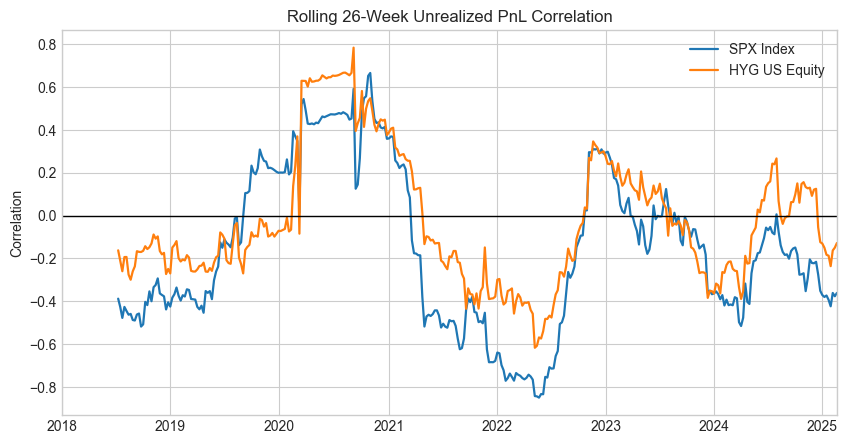

In [17]:
rolling_corr = results[["unrealized_pnl", "SPX Index", "HYG US Equity"]].rolling(26).corr()
unrealized_corr = rolling_corr.loc[(slice(None), "unrealized_pnl"), ["SPX Index", "HYG US Equity"]]
unrealized_corr.index = unrealized_corr.index.droplevel(1)

fig, ax = plt.subplots(figsize=(10, 5))
unrealized_corr.plot(ax=ax, linewidth=1.6)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Rolling 26-Week Unrealized PnL Correlation")
ax.set_ylabel("Correlation")
ax.set_xlabel("")
plt.show()

## Stress Testing

Stress windows help determine whether the strategy behaves like a true relative-value portfolio or simply hides equity/credit exposure until markets become disorderly.

In [18]:
stress_periods = {
    "COVID shock": ("2020-02-19", "2020-04-08"),
    "2022 rates/credit selloff": ("2022-01-05", "2022-10-12"),
    "AI/growth rebound": ("2023-01-04", "2023-12-27"),
    "Late sample": ("2024-01-03", "2025-03-12"),
}
stress_rows = []
for name, (start, end) in stress_periods.items():
    window = results_core.loc[start:end]
    if window.empty:
        continue
    stress_rows.append({
        "period": name,
        "realized_total": (1 + window["realized_pnl"].fillna(0)).prod() - 1,
        "unrealized_total": (1 + window["unrealized_pnl"].fillna(0)).prod() - 1,
        "available_capital_total": (1 + window["available capital"].fillna(0)).prod() - 1,
        "spx_total": (1 + results.loc[start:end, "SPX Index"].fillna(0)).prod() - 1,
        "hyg_total": (1 + results.loc[start:end, "HYG US Equity"].fillna(0)).prod() - 1,
    })
stress = pd.DataFrame(stress_rows).set_index("period")
stress.style.format("{:.4f}")

,realized_total,unrealized_total,available_capital_total,spx_total,hyg_total
period,,,,,
COVID shock,-0.0007,-0.0024,0.0473,-0.1863,-0.1254
2022 rates/credit selloff,0.0055,0.0096,0.1610,-0.2537,-0.1779
AI/growth rebound,0.0111,0.0527,0.0310,0.2639,0.0731
Late sample,0.1161,0.1688,0.3257,0.2850,0.0232


## Research Conclusions

The project supports the idea that convertible arbitrage can be framed as a systematic relative-value strategy, but the strongest version needs stronger data controls and richer trade attribution. The current signal produces a useful valuation lens; the risk diagnostics show that the strategy is not simply long equity, though it still has meaningful credit/liquidity exposure.

The biggest upgrade for a future production version would be a trade-level ledger: each position should record entry signal, bond PnL, stock hedge PnL, Treasury hedge PnL, coupons, dividends, borrow costs, transaction costs, slippage, and exit reason.